<a href="https://colab.research.google.com/github/enzocatorano/ExtracurricularSinc/blob/master/1_introduccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ejercicio 1

Retomemos el **mapa logístico** $\{\ell_n\}$ visto en la teoría, dado por la relación de recurrencia $\ell_n(x)=r\ell_{n-1}(x)\big(1-\ell_{n-1}(x)\big)$, donde el estado inicial es $\ell_1(x)=x$. Pueden fijar $r=4$ y $n=4$ para simplificar (como hicimos en la clase teórica.)
- a) ¿Cómo sería el grafo computacional de $\ell_n(x)$? Para construir este grafo, primero a partir de las operaciones base de `suma` y `producto` construir la operación $f(x)=rx(1-x)$, luego usar esta función para construir el grafo de $\ell_n$, con $\ell_0(x)=x$ como el nodo raíz.

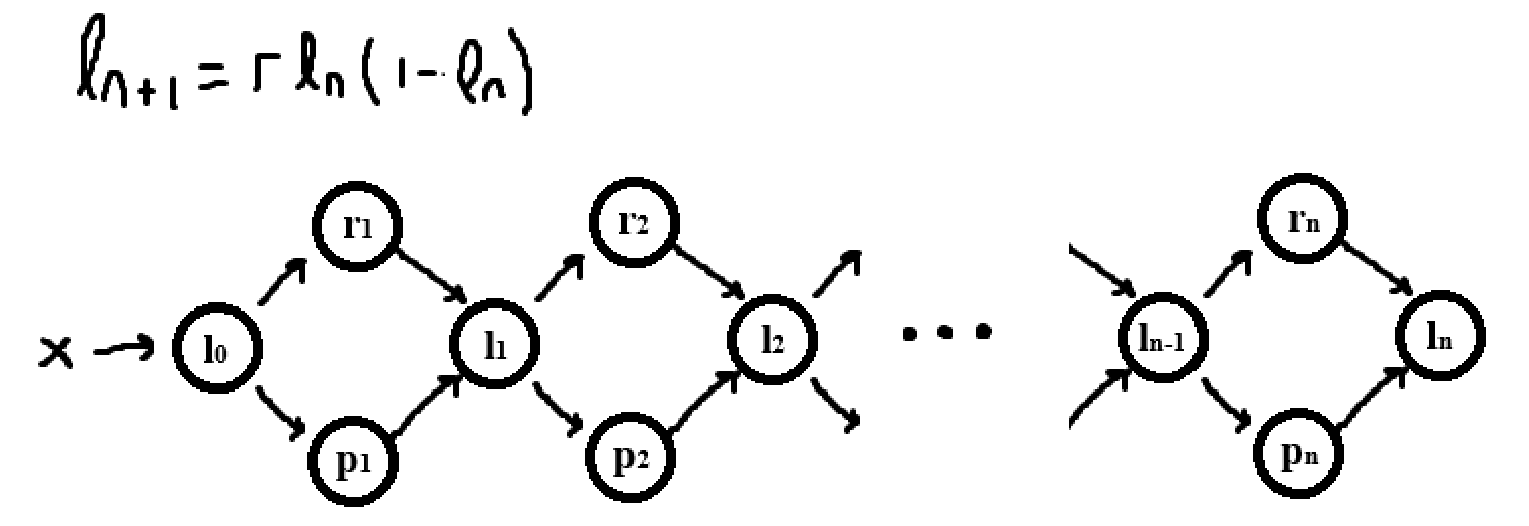

r_i = r * l_(i-1)

p_i = 1 - l_(i-1)

l_i = r_i * p_i

- b) Escribir una función que implemente $\ell_n$ usando sólo elementos de la biblioteca estándar de Python, y `numpy` si lo desean. Pueden hacerlo de manera iterativa y/o recursiva.
- c) Escribir una función que calcule $\ell'_n(x)=\frac{d\ell_n(x)}{dx}$, de nuevo usando sólo elementos de la biblioteca estándar:
  - i. Usando diferenciación numérica con diferencias finitas. Observar qué pasa si hacemos variar $h$ en un rango amplio de valores. Examinar cómo depende este comportamiento de que se use `float32` o `float64`. Si usan `numpy`, pueden cambiar el tipo de datos con `numpy.float32` ó `numpy.float64`.
  - ii. Usando diferenciación automática. Como vimos en la teoría, esto implica ir llevando $(\ell_i(x), \ell'_i(x))$ para cada $i$ a partir de 1 hasta llegar a $n$ (en el modo directo), o computar los distintos $\ell_i(x)$ y luego calcular las derivadas en el orden inverso. Nuevamente, la implementación puede ser iterativa o recursiva.

In [3]:
# funcion
# l_n+1 = r*l_n*(1-l_n)

# derivada local
# l'_n+1 = r*(1-2*l_n)

import numpy as np

def l_n (n, r, x_0):
  x = x_0
  valores = [x]
  for i in range(n):
    x = r*x*(1-x)
    valores.append(x)
  return x, valores

def dl_n (n, r, x_0):
  dval = 1
  dvalores = [dval]
  val = l_n(n - 1, r, x_0)[1]   # esto obtiene todos los valores del "forward"
  for i in range(n):
    dval *= r*(1-2*val[i])      # multiplica la derivada local con todo lo anterior (regla de la cadena)
    dvalores.append(dval)
  return dval, dvalores

def derivada_diferencias_finitas(n, r, x_0, h = 1e-5, dtype = np.float64):
  h = dtype(h)
  x_0 = dtype(x_0)
  r = dtype(r)
  l_n_x0_1 = dtype(l_n(n, r, x_0 - h)[0])
  l_n_x0_2 = dtype(l_n(n, r, x_0 + h)[0])
  return (l_n_x0_2 - l_n_x0_1) / (2*h)

0.2332734331837175 0.23841858


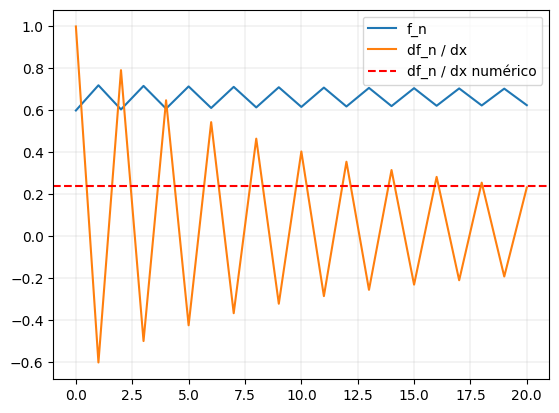

In [37]:
n = 20
r = 3
x_0 = 0.6
h = 1e-6
dtype = np.float32

y = l_n(n, r, x_0)
dy = dl_n(n, r, x_0)
ddfy = derivada_diferencias_finitas(n, r, x_0, h, dtype)
print(dy[0], ddfy)

import matplotlib.pyplot as plt

plt.plot(y[1], label = 'f_n')
plt.plot(dy[1], label = 'df_n / dx')
plt.axhline(y = ddfy, color = 'r', linestyle = '--', label = 'df_n / dx numérico')  # linea horizontal en valor de derivada numerica
plt.grid(linewidth = 0.2)
plt.legend()
plt.show()

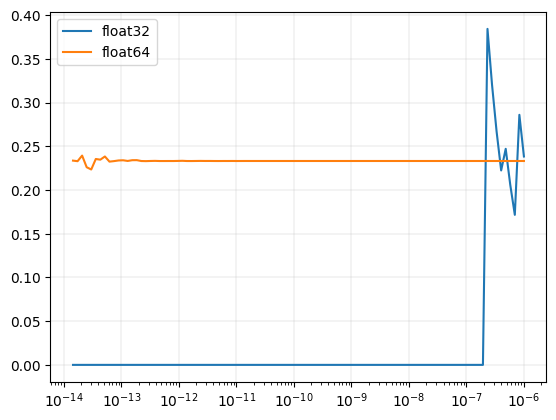

0.23369715634153118


In [44]:
# mismos parametros que antes
n = 20
r = 3
x_0 = 0.6
h = 1e-6

factor = 1.2
cantidad = 100
valores32 = []
valores64 = []
for i in range(0, cantidad):
  valores32.append(derivada_diferencias_finitas(n, r, x_0, h/(factor**i), np.float32))
  valores64.append(derivada_diferencias_finitas(n, r, x_0, h/(factor**i), np.float64))

h_usado = h / factor**np.arange(0, cantidad)

plt.plot(h_usado, valores32, label = "float32")
plt.plot(h_usado, valores64, label = "float64")
plt.xscale("log")       # eje x logaritmico
plt.grid(linewidth = 0.2)
plt.legend()
plt.show()
print(valores64[-1])

In [ ]:
print(np.float32(np.pi), np.float64(np.pi))

3.1415927 3.141592653589793


- d) Finalmente, realizar diferenciación automática usando PyTorch.

Las distintas formas exactas deben dar el mismo resultado, lo cual pueden usar para corroborar las soluciones.

In [ ]:
import torch

def l_n_torch (n, r, x_0, ):
  x = torch.tensor(x_0, dtype = torch.float64, requires_grad = True)
  for i in range(n):
    x = r*x*(1 - x)
    x.backward()
  return x, x.grad

[0.6, 0.72, 0.6048000000000001, 0.71705088, 0.6086667464736769, 0.7145746146324768, 0.6118732042659721, 0.7124531585017921, 0.6145909663278372, 0.7106067313081575, 0.6169344141830806, 0.7089790283389793, 0.6189832971434882, 0.7075289250025932, 0.6207952358618042, 0.7062255329792734, 0.6224130886422439, 0.7050451071871985, 0.6238695120557709, 0.7039690319491957, 0.625189902017124, 0.7029824652988287, 0.6263943563436294, 0.7020734000534389, 0.6274990229725286, 0.7012319974231519, 0.6285170496392657, 0.7004501038560556, 0.6294592675922897, 0.6997208941034039, 0.6303346933756108, 0.6990386031080567, 0.6311509034183805, 0.6983983215976279, 0.6319143179617327, 0.6977958381500727, 0.6326304192315307, 0.6972275156834052, 0.6333039211720565, 0.6966901938004624, 0.6339389029882098, 0.6961811107989448, 0.6345389152970764, 0.6956978408120583, 0.6351070653044949, 0.6952382427144209, 0.6356460857453546, 0.6948004182658917, 0.636158391130301, 0.6943826775744238, 0.6366461239769928, 0.6939835104061929

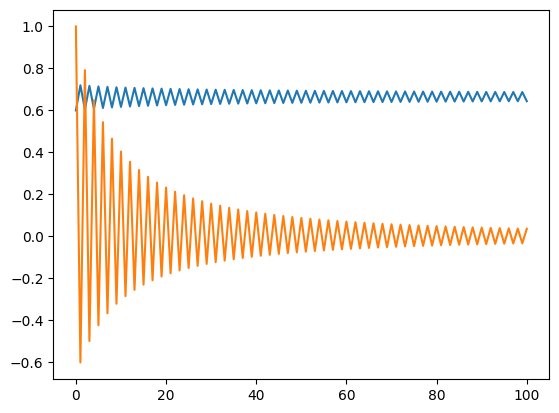

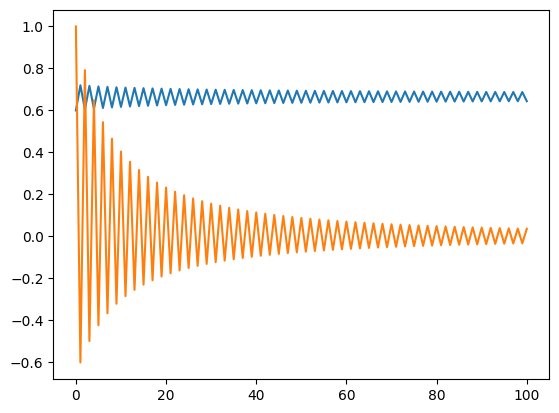

In [47]:
import torch
import matplotlib.pyplot as plt

n = 100
r = 3
x_0 = 0.6

x = torch.tensor(x_0, dtype = torch.float64, requires_grad = True)
valores_y = [x.item()]
derivadas = [1]
y = x
for i in range(n):
  y = r*y*(1 - y)
  valores_y.append(y.item())
  y.backward(retain_graph = True)
  derivadas.append(x.grad.item())
  x.grad.zero_()
print(valores_y, derivadas)

y = l_n(n, r, x_0)
dy = dl_n(n, r, x_0)
print(y[1], dy[1])

plt.plot(y[1])
plt.plot(dy[1])
plt.show()

plt.plot(valores_y)
plt.plot(derivadas)
plt.show()

---
## Ejercicio 2:

Retomemos la función de dos variables vista en la clase teórica, $f(x_1,x_2)= \ln(x_1) + x_1 x_2 - \sin(x_2)$.
- a) Construir el grafo computacional, donde las funciones base sean $+$, $-$,$\times$, $\sin$ y $\log$ (es decir, cada nodo debe realizar sólo una de estas operaciones)
- b) Implementar el modo reverso de cómputo de gradientes con Python puro, como fue realizado en la teoría.
- c) Implementar lo mismo pero ir guardando en cada paso tanto el valor del nodo como de las derivadas del mismo respecto a las entradas.
- d) Implementar lo mismo pero en PyTorch.

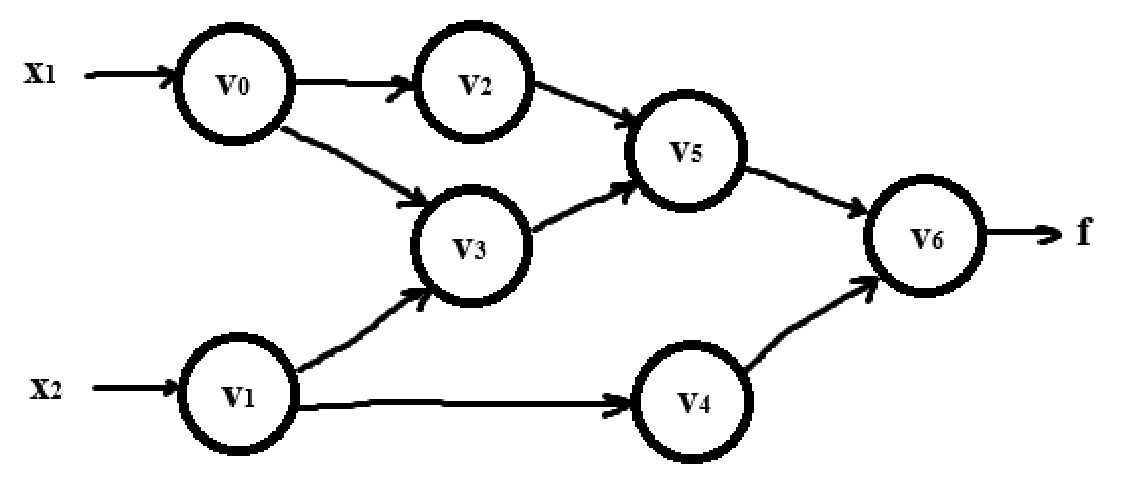

In [ ]:
# v_0 = x_1
# v_1 = x_2
# v_2 = ln(v_0)
# v_3 = v_0 * v_1
# v_4 = sin(v_1)
# v_5 = v_2 + v_3
# v_6 = v_5 - v_4

In [51]:
import numpy as np
import math
import torch

def f_grad_reverso (x1, x2):
    # Forward:
    v0 = x1
    v1 = x2
    v2 = np.log(v0)
    v3 = v0 * v1
    v4 = np.sin(v1)
    v5 = v2 + v3
    v6 = v5 - v4
    f = v6

    # Backward:
    df = 1.0

    # n6: v6 = v5 - v4
    dv5 = df * 1.0                  # derivada de f respecto de v5
    dv4 = df * (-1.0)               # derivada de f respecto de v4
    # n5: v5 = v2 + v3
    dv2 = dv5 * 1.0                 # derivada de f respecto de v2
    dv3 = dv5 * 1.0                 # derivada de f respecto de v3
    # n4: v4 = sin(v1)
    dv1 = dv4 * np.cos(v1)          # derivada de f respecto de v1 (incompleta)
    # n3: v3 = v0 * v1
    dv0 = dv3 * v1                  # derivada de f respecto de v0 (incompleta)
    dv1 += dv3 * x1                 # derivada de f respecto de v1 (completa)
    # n2: v2 = ln(v0)
    dv0 += dv2 * (1/v0)             # derivada de f respecto de v0 (completa)

    return f, dv0, dv1

print(f_grad_reverso(2, 5))             # salida y ambas derivadas

def f_grad_directo (x1, x2):
    # voy haciendo el forward y consiguiendo las derivadas respecto de cada variable en cada paso
    v0 = x1
    dv0_x1 = 1
    dv0_x2 = 0

    v1 = x2
    dv1_x1 = 0
    dv1_x2 = 1

    v2 = np.log(v0)
    dv2_x1 = 1/v0 * dv0_x1
    dv2_x2 = 1/v0 * dv0_x2

    v3 = v0 * v1
    dv3_x1 = v1 * dv0_x1 + v0 * dv1_x1
    dv3_x2 = v0 * dv1_x2 + v1 * dv0_x2

    v4 = np.sin(v1)
    dv4_x1 = np.cos(v1) * dv1_x1
    dv4_x2 = np.cos(v1) * dv1_x2

    v5 = v2 + v3
    dv5_x1 = 1*dv2_x1 + 1*dv3_x1
    dv5_x2 = 1*dv2_x2 + 1*dv3_x2

    v6 = v5 - v4
    dv6_x1 = 1*dv5_x1 + (-1)*dv4_x1
    dv6_x2 = 1*dv5_x2 + (-1)*dv4_x2

    return v6, dv6_x1, dv6_x2

print(f_grad_directo(2, 5))

def f_grad_pytorch (x1, x2):
    x1 = torch.tensor(x1, requires_grad = True, dtype = torch.float64)
    x2 = torch.tensor(x2, requires_grad = True, dtype = torch.float64)
    v0 = x1
    v1 = x2
    v2 = torch.log(v0)
    v3 = v0 * v1
    v4 = torch.sin(v1)
    v5 = v2 + v3
    v6 = v5 - v4
    f = v6
    f.backward()
    return f.item(), x1.grad.item(), x2.grad.item()

print(f_grad_pytorch(2, 5))

(np.float64(11.652071455223084), 5.5, np.float64(1.7163378145367738))
(np.float64(11.652071455223084), np.float64(5.5), np.float64(1.7163378145367738))
(11.652071455223084, 5.5, 1.7163378145367738)


# Ejercicio 3

Dadas las siguientes dos funciones:
- 1) $f(x, y, z, w) = -zx^2 + 2wy$ evaluada en el punto $(x,y,z,w)=(2,4,1,3)$,
- 2) $g(x,y,z,w) = -3\big(4xy + \max(w, z)\big)$ evaluada en el punto $(x,y,z,w)=(5,2,4,3)$,

se solicita:

- a) Dibujar el grafo computacional, las funciones base ahora serían $+$, $\times$ y $\max$ (y $(⋅)^2$ si lo desean).
- b) Obtener las derivadas manualmente por el modo reverso.
- c) Implementar el modo reverso con Python estándar (sin PyTorch).
- d) Implementarlo con PyTorch.

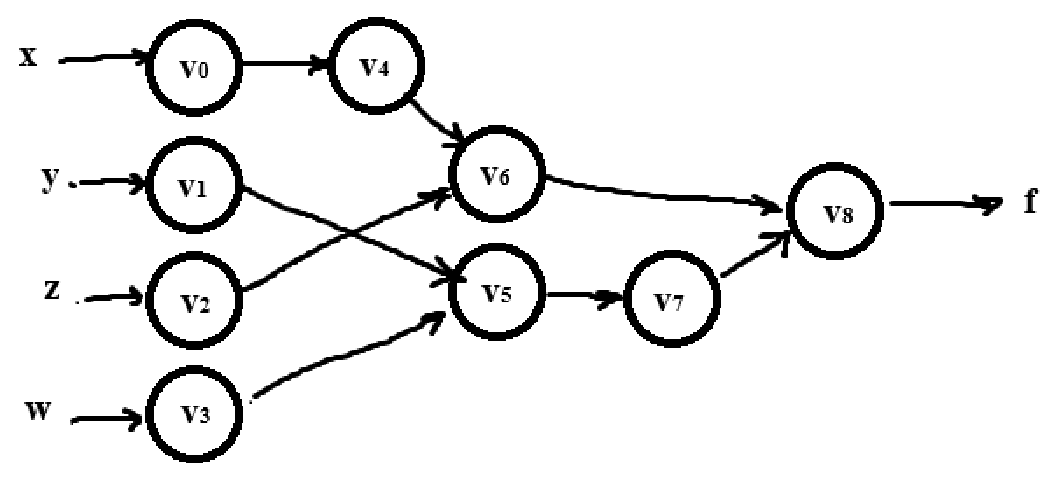

In [ ]:
# v0 = x
# v1 = y
# v2 = z
# v3 = w
# v4 = v0**2
# v5 = v1 * v3
# v6 = v4 * v2
# v7 = 2 * v5
# v8 = v7 - v6

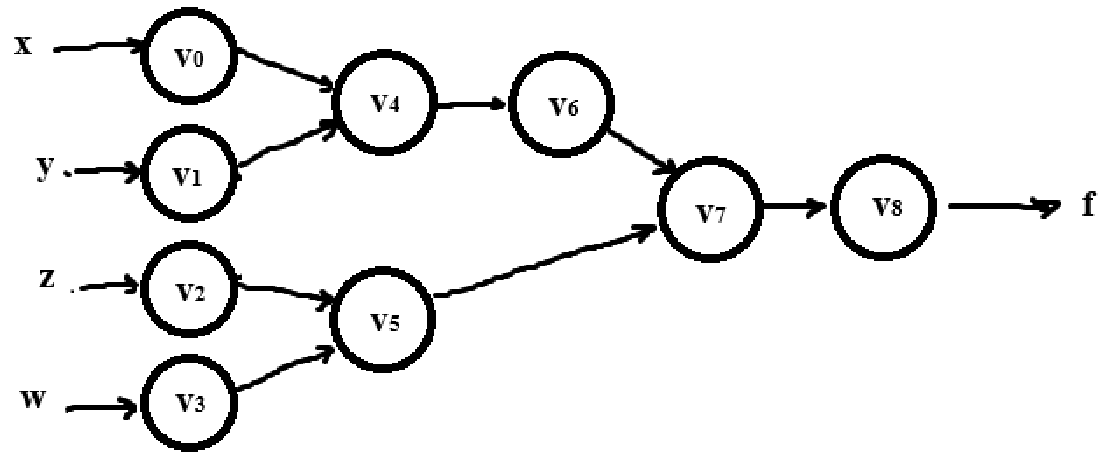

In [ ]:
# v0 = x
# v1 = y
# v2 = z
# v3 = w
# v4 = v0 * v1
# v5 = max(v2, v3)
# v6 = 4 * v4
# v7 = v5 + v6
# v8 = (-3) * v7

In [ ]:
# forward


1)  f(x,y,z,w)=−zx2+2wy  evaluada en el punto  (x,y,z,w)=(2,4,1,3) ,

2)  g(x,y,z,w)=−3(4xy+max(w,z))  evaluada en el punto  (x,y,z,w)=(5,2,4,3) ,

In [52]:
x, y, z, w = 2, 4, 1, 3
v = torch.tensor([x, y, z, w], dtype = torch.float64, requires_grad = True)
f = -v[2]*v[0]**2 + 2*v[3]*v[1]
f.backward()
print(f, v.grad)

x, y, z, w = 5, 2, 4, 3
v = torch.tensor([x, y, z, w], dtype = torch.float64, requires_grad = True)
f = 3*(4*v[0]*v[1] + torch.max(torch.tensor([v[2], v[3]])))
f.backward()
print(f, v.grad)

# Preguntar aca sobre la derivada de la funcion max()

tensor(20., dtype=torch.float64, grad_fn=<AddBackward0>) tensor([-4.,  6., -4.,  8.], dtype=torch.float64)
tensor(132., dtype=torch.float64, grad_fn=<MulBackward0>) tensor([24., 60.,  0.,  0.], dtype=torch.float64)


# Ejercicio 4

Implementar el algoritmo de gradiente descendente, utilizando diferenciación automática, para minimizar la función cuadrática: $f(x) = 2x^2 + x + 4$
- a) Sin usar optimizador.
- b) Usando el SGD de `torch.optim` como optimizador.

In [53]:
# f(x) = 2x**2 + x + 4
# sin optimizador
paso = 1e-1
erd = 1e-10
x_0 = 0
print('Iteracion, x, f(x), df(x)')
x = torch.tensor(x_0, dtype = torch.float64, requires_grad = True)
for i in range(10000):
  f = 2*x**2 + x + 4
  f.backward()
  print(i + 1, x.item(), f.item(), x.grad.item())
  with torch.no_grad():
    x -= paso*x.grad.item()         # esto es SGD
    if abs(x.grad.item()) <= erd:
      break
    x.grad.zero_()

Iteracion, x, f(x), df(x)
1 0.0 4.0 1.0
2 -0.1 3.92 0.6
3 -0.16 3.8912 0.36
4 -0.196 3.880832 0.21599999999999997
5 -0.21760000000000002 3.87709952 0.12959999999999994
6 -0.23056000000000001 3.8757558272 0.07775999999999994
7 -0.23833600000000002 3.875272097792 0.04665599999999992
8 -0.2430016 3.87509795520512 0.027993599999999952
9 -0.24580096 3.8750352638738432 0.01679615999999995
10 -0.247480576 3.8750126949945836 0.01007769599999997
11 -0.2484883456 3.8750045701980502 0.006046617600000026
12 -0.24909300736 3.875001645271298 0.003627970559999971
13 -0.24945580441600002 3.8750005922976674 0.0021767823359999383
14 -0.24967348264960001 3.8750002132271604 0.0013060694015999408
15 -0.24980408958976 3.875000076761778 0.0007836416409600089
16 -0.249882453753856 3.87500002763424 0.0004701849845759609
17 -0.2499294722523136 3.8750000099483266 0.00028211099074559876
18 -0.24995768335138815 3.8750000035813974 0.00016926659444738146
19 -0.2499746100108329 3.875000001289303 0.0001015599566683844

In [54]:
# f(x) = 2x**2 + x + 4
# con optimizador
paso = 1e-1
erd = 1e-10
x_0 = 0
x = torch.tensor(x_0, dtype = torch.float64, requires_grad = True)
optimizador = torch.optim.SGD([x], lr = paso)
print('Iteracion, x, f(x), df(x)')
for i in range(1000):
  f = 2*x**2 + x + 4
  f.backward()
  print(i + 1, x.item(), f.item(), x.grad.item())
  optimizador.step()
  if abs(x.grad.item()) <= erd:
    break
  optimizador.zero_grad()

Iteracion, x, f(x), df(x)
1 0.0 4.0 1.0
2 -0.1 3.92 0.6
3 -0.16 3.8912 0.36
4 -0.196 3.880832 0.21599999999999997
5 -0.21760000000000002 3.87709952 0.12959999999999994
6 -0.23056000000000001 3.8757558272 0.07775999999999994
7 -0.23833600000000002 3.875272097792 0.04665599999999992
8 -0.2430016 3.87509795520512 0.027993599999999952
9 -0.24580096 3.8750352638738432 0.01679615999999995
10 -0.247480576 3.8750126949945836 0.01007769599999997
11 -0.2484883456 3.8750045701980502 0.006046617600000026
12 -0.24909300736 3.875001645271298 0.003627970559999971
13 -0.24945580441600002 3.8750005922976674 0.0021767823359999383
14 -0.24967348264960001 3.8750002132271604 0.0013060694015999408
15 -0.24980408958976 3.875000076761778 0.0007836416409600089
16 -0.249882453753856 3.87500002763424 0.0004701849845759609
17 -0.2499294722523136 3.8750000099483266 0.00028211099074559876
18 -0.24995768335138815 3.8750000035813974 0.00016926659444738146
19 -0.2499746100108329 3.875000001289303 0.0001015599566683844

El resultado es el mismo, porque torch.optim.SGD (stochastic gradient descent) es un objeto que modifica los parámetros del modelo especificados en el primer elemento entre paréntesis, para reducir una funcion perdida mediante:

x <- x - ls*df/dx

nótese que el optimizador no tiene una función de pérdida explicita especificada. Aquello que minimiza, es cual sea la función que, directa o indirectamente dependa del parámetro a optimizar (x en este caso).

# Ejercicio 5

Definimos el **perceptrón simple** con función de activación **sigmoidea** como $\phi(v(\mathbf{x}))=\frac{1}{1+e^{-v(\mathbf{x})}}$ siendo $v(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x}$ la salida lineal del perceptrón, donde $\mathbf{x}=(-1,x_1, x_2, ...,x_m)$ y $\mathbf{w}=(b,w_1, w_2, ...,w_m)$. Notar que llamamos $w_0\equiv b$ para enfatizar su interpretación como sesgo o _bias_.
- a) Crear una clase `PerceptronSimple` implementando retropropagación usando PyTorch (calculando gradiente respecto de $\mathbf{w}$), con el error cuadrático medio (MSE) como función de pérdida. <!--- Por ahora, no usar `torch.nn.Module`, `torch.optim` ni `torch.nn.functional` (esto lo veremos en los ejercicios posteriores). --->
- b) Agregar a la función de pérdida un término de regularización $L_2$ sobre los pesos de la red (conocido como _weight decay_ ya que induce que los pesos sean más pequeños en valor absoluto). Recordar que $L_2(\mathbf{w})=||\mathbf{w}||_2^2=\sum_{i}w^2_{i}$. Ajustar la ponderación de este término con un parámetro llamado `weight_decay` que se le pase al constructor de la clase.
- c) Ahora crear otra clase `PerceptronSimpleModule`, pero esta vez heredando de `torch.nn.Module`. Tengan en cuenta que si se utiliza la capa `Linear`, el manejo del bias **se realiza automáticamente** (por omisión en la llamada a `nn.Linear(...)`).

In [55]:
from random import random
# Hago un perceptron simple
import torch
from torch import nn

# A.
# haciendolo "a mano"
class PerceptronSimple ():
                                # agrego la regularizacion L_2
  def __init__ (self, n_entradas, weight_decay = 0, semilla = None):
    if semilla != None:
      torch.manual_seed(semilla)
      self.semilla = semilla
    self.n_entradas = n_entradas
    self.weight_decay = weight_decay
    self.pesos = torch.rand(n_entradas + 1, requires_grad = True)

  ###############################################################################################

  def correr(self, x_entrada):
    if len(x_entrada.shape) == 1:
        x_entrada = x_entrada.unsqueeze(0)  # Convierto a matriz de 1 fila
    if x_entrada.shape[1] != self.n_entradas:
        raise ValueError(f"Dimensión incorrecta: se esperaban {self.n_entradas} entradas por dato.")
    sesgo = -torch.ones((x_entrada.shape[0], 1))  # Vector columna de -1 de dim igual a n° de datos
    x_entrada = torch.cat([sesgo, x_entrada], dim = 1) # Añado el sesgo a todos los x
    y = torch.matmul(x_entrada, self.pesos)  # matmul es multiplicacion de matrices
    z = 1/(1 + torch.exp(-y))                # activacion
    return z

  def entrenar (self, entrada, salida_esperada, lr = 1e-3):
    salida = self.correr(entrada)
    mse = torch.mean((salida_esperada.T - salida).pow(2)) # estos son metodos de tensores pytorch
    l2 = self.weight_decay*((self.pesos).pow(2).sum()) # agrego la regularizacion L_2
    perdida = mse + l2
    perdida.backward()
    with torch.no_grad():
      self.pesos -= lr*self.pesos.grad
      self.pesos.grad.zero_()
    return perdida.item()

  # hacer esto asi me deja libertad para despues poder hacer actualizacion
  # de los pesos ya sea por dato individual o por lotes
  ###############################################################################################

  def evaluar (self, entrada, salida_esperada):
    salida = self.correr(entrada)
    with torch.no_grad():
      error = torch.mean((salida_esperada.T - salida).pow(2))
      desv_error = torch.std((salida_esperada.T - salida).pow(2))
    return salida, error, desv_error

##################################################################################################
##################################################################################################
##################################################################################################
# C.
# usando module

class PerceptronSimpleModule (nn.Module):

  def __init__ (self, n_entradas, weight_decay = 0, semilla = None):
    super(PerceptronSimpleModule, self).__init__()
    if semilla != None:
      torch.manual_seed(semilla)
      self.semilla = semilla
    self.n_entradas = n_entradas
    self.weight_decay = weight_decay
    self.fc = torch.nn.Linear(n_entradas, 1) # estas son dos capas continuas conectadas

  def correr (self, x_entrada):
    if len(x_entrada.shape) == 1:
        x_entrada = x_entrada.unsqueeze(0)
    if x_entrada.shape[1] != self.n_entradas:
        raise ValueError(f"Dimensión incorrecta: se esperaban {self.n_entradas} entradas por dato.")
    return torch.sigmoid(self.fc(x_entrada))

  def entrenar (self, entrada, salida_esperada, lr = 1e-3):
    optimizador = torch.optim.SGD(self.parameters(), lr = lr, weight_decay = self.weight_decay)
    salida = self.correr(entrada)
    perdida = nn.MSELoss(reduction = "mean")(salida_esperada, salida)
    perdida.backward()
    optimizador.step()
    optimizador.zero_grad()
    return perdida.item()

  def evaluar (self, entrada, salida_esperada):
    salida = self.correr(entrada)
    with torch.no_grad():
      error = (torch.mean((salida_esperada - salida).abs()))
      desv_error = torch.std((salida_esperada - salida).abs())
    return salida, error, desv_error

In [57]:
# los pruebo

perceptron_manual = PerceptronSimple(n_entradas = 2, weight_decay = 0.00)
perceptron_nn = PerceptronSimpleModule(n_entradas = 2, weight_decay = 0.00)

# Datos de prueba
entrada = torch.tensor([
    [-3, 2],  # -1
    [7, 0],   # 7
    [4, -2],  # 2
    [3, 2],   # 5
    [-1, -5], # -6
    [5, 1],   # 6
    [-1, 7],  # 6
    [2, 7],   # 10
    [-4, 10],   # 6
    [6, -3],  # 3
    [-2, 9],  # 7
    [4, 2],   # 6
    [8, -4],  # 4
    [1, 7],   # 8
    [-5, 1],  # -4
    [6, 3]    # 9
], dtype=torch.float32)

# Salidas esperadas (0 para menores o iguales a 5, 1 para mayores)
salida_esperada = torch.tensor([
    0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1
], dtype=torch.float32).unsqueeze(1)

# Entrenamiento
for epoch in range(1000):
  for i in range(12):
    loss_manual = perceptron_manual.entrenar(entrada[i], salida_esperada[i])
    loss_nn = perceptron_nn.entrenar(entrada[i], salida_esperada[i])
  if epoch % 100 == 0:
    print(f"Época {epoch}, Pérdida manual: {loss_manual}, Perdida nn: {loss_nn}")

# Evaluación
salida_manual, error_manual, desv_error_manual = perceptron_manual.evaluar(entrada, salida_esperada)
salida_nn, error_nn, desv_error_nn = perceptron_nn.evaluar(entrada, salida_esperada)

print(salida_esperada)
print(f"Salida manual: {salida_manual}, Error manual: {error_manual}, Desviación manual: {desv_error_manual}")
print(f"Salida nn: {salida_nn}, Error nn: {error_nn}, Desviación nn: {desv_error_nn}")

/tmp/ipython-input-55-3505704783.py:33: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  mse = torch.mean((salida_esperada.T - salida).pow(2)) # estos son metodos de tensores pytorch
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Época 0, Pérdida manual: 0.0007516496116295457, Perdida nn: 0.29388827085494995


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Época 100, Pérdida manual: 0.002823946764692664, Perdida nn: 0.1409926563501358
Época 200, Pérdida manual: 0.01498254481703043, Perdida nn: 0.06700371205806732


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


...

Época 800, Pérdida manual: 0.04402969777584076, Perdida nn: 0.04139465466141701


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Época 900, Pérdida manual: 0.045414410531520844, Perdida nn: 0.04160930961370468


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor([[0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.]])
Salida manual: tensor([0.2463, 0.7448, 0.2281, 0.7209, 0.0080, 0.7330, 0.9377, 0.9769, 0.9724,
        0.2391, 0.9740, 0.7847, 0.2503, 0.9677, 0.0805, 0.9316],
       grad_fn=<MulBackward0>), Error manual: 0.05956902354955673, Desviación manual: 0.12608273327350616
Salida nn: tensor([[0.6054],
        [0.6966],
        [0.3806],
        [0.7725],
        [0.0737],
        [0.7363],
        [0.9524],
        [0.9675],
        [0.9816],
        [0.3357],
        [0.9778],
        [0.7949],
        [0.2935],
        [0.9630],
        [0.4262],
        [0.8890]], grad_fn=<SigmoidBackward0>), Error nn: 0.24552688002586365, Desviación nn: 0.22374394536018372


# Ejercicio 6

Implementemos un `PerceptronMulticapa` (un MLP o _multi-layer perceptron_) con función de activación ReLU.
Nuevamente, crear una clase, heredando de `torch.nn.Module`. El constructor de la misma debe recibir como argumentos la cantidad de características (dimensiones) de los datos de entrada, la cantidad de neuronas en la capa oculta (con una sola capa oculta), y la cantidad de salidas esperadas. También debe haber un argumento adicional que indique si la salida puede tomar cualquier valor real o debe estar entre 0 y 1 (función de activación sigmoide en la salida). La función de activación ReLU  deberá implementarse con `nn.ReLU`, instanciándola (¿cómo sería con `nn.functional.relu`?)

In [ ]:
import torch
torch.cuda.is_available()
from torch import nn

class PerceptronMulticapa (nn.Module):

  def __init__ (self, n_entrada, n_oculta, n_salida, f_act = 'relu', weight_decay = 0.0, semilla = None):
    super(PerceptronMulticapa, self).__init__()
    if semilla != None:
      torch.manual_seed(semilla)
      self.semilla = semilla
    self.n_entrada = n_entrada
    self.n_oculta = n_oculta
    self.n_salida = n_salida
    if f_act == 'relu':
      self.f_act = nn.ReLU()
    elif f_act == 'sigmoid':
      self.f_act = nn.Sigmoid()
    self.weight_decay = weight_decay
    self.fc1 = torch.nn.Linear(n_entrada, n_oculta, dtype = torch.float32)
    self.fc2 = torch.nn.Linear(n_oculta, n_salida, dtype = torch.float32)

  def correr (self, x_entrada):
    if len(x_entrada.shape) == 1:
      x_entrada = x_entrada.unsqueeze(0)
    if x_entrada.shape[1] != self.n_entrada:
      raise ValueError(f"Dimensión incorrecta: se esperaban {self.n_entrada} entradas por dato.")
    y1 = self.fc1(x_entrada)
    z1 = self.f_act(y1)
    y2 = self.fc2(z1)
    z2 = self.f_act(y2)
    return z2

  def entrenar (self, x_entrada, salida_esperada, lr = 1e-3):
    optimizador = torch.optim.SGD(self.parameters(), lr = lr, weight_decay = self.weight_decay)
    salida = self.correr(x_entrada)
    perdida = nn.MSELoss(reduction = "mean")(salida_esperada, salida)
    perdida.backward()
    optimizador.step()
    optimizador.zero_grad()
    return perdida.item()

  def evaluar (self, x_entrada, salida_esperada):
    salida = self.correr(x_entrada)
    with torch.no_grad():
      error = torch.mean((salida_esperada.T - salida).pow(2))
      desv_error = torch.std((salida_esperada.T - salida).pow(2))
    return salida, error, desv_error

# Ejercicio 7

Finalmente, vamos a realizar un bucle de entrenamiento del MLP sobre los datos de `Iris`, usando ahora todas las prestaciones de PyTorch. La tarea es clasificar la especie de planta en base a distintas dimensiones de la flor.
  - a) Primero que nada, debemos [descargar la base de datos de Iris](https://www.kaggle.com/datasets/uciml/iris) y agregarla a nuestro entorno. Es simplemente un archivo CSV.

- b) Crear una clase que implemente un dataset de PyTorch, heredando de `torch.utils.data.Dataset`. Recordar que esto implica definir los dos métodos especiales `__getitem__` y `__len__`. El constructor debe recibir como argumento la ruta al archivo `Iris.csv` que descargaron antes.

- c) Crear particiones de datos de entrenamiento, validación y testeo con sus respectivos `Dataset` y `Dataloader`. **Ayuda**: recordar la función `sklearn.model_selection.train_test_split`. También existe `torch.utils.data.random_split` para el mismo fin.

- d) Inicializar el modelo del **Ejercicio 6** y un optimizador tipo SGD con una tasa de aprendizaje de $10^{-4}$.

- e) Escribir y ejecutar el bucle de entrenamiento. Debe haber dos bucles, el externo sobre las épocas y el interno sobre los batches (es decir, iterando sobre el `DataLoader`). Usar el optimizador definido antes para gestionar la actualización de los pesos del MLP. Definir un número máximo de épocas y un criterio razonable para interrumpir el entrenamiento tempranamente si alguna métrica no mejora (¿sobre qué partición debemos monitorear la métrica?).


In [ ]:
# si quisiera cargar desde google drive haria esto
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import pandas as pd
from typing import Tuple
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

class MiDataset (Dataset):

  def __init__ (self, ruta_archivo):
    self.data = pd.read_csv(ruta_archivo)
    self.etiquetas = ['Iris-setosa','Iris-versicolor','Iris-virginica']
    self.vec_salida = torch.tensor([0, 0, 0], dtype = torch.float32)

    self.X = self.data.iloc[:, :-1].values # esto los vuelve arrays numpy
    self.Y = self.data.iloc[:, -1].values
    # tuve que normalizar para ver si asi andaban las cosas
    self.normalizador = MinMaxScaler()
    self.X = self.normalizador.fit_transform(self.X)

            # aca hay 2 'hints', no afectan al codigo, son de ayuda al usuario
  def __getitem__ (self, indice: int) -> Tuple:
    x = torch.tensor(self.X[indice], dtype = torch.float32)
    indice_etiqueta = self.etiquetas.index(self.Y[indice])
    self.vec_salida[indice_etiqueta] = 1
    y = self.vec_salida.clone()
    self.vec_salida[indice_etiqueta] = 0
    return x, y

  def __len__ (self):
    return self.data.shape[0]

  def particionar (self, ratio_e = 0.7, semilla = None, validacion = True):
    if ratio_e >= 1:
      raise ValueError(f'Ratio mal definido. Obervar valor.')
    indices = list(range(len(self)))
    i_entrenamiento, i_resto = train_test_split(
        indices, train_size = 1 - ratio_e, random_state = semilla)
    if validacion == True:
      i_validacion, i_prueba = train_test_split(
      i_resto, train_size = 0.5, random_state = semilla)
      datos_entrenamiento = Subset(self, i_entrenamiento)
      datos_validacion = Subset(self, i_validacion)
      datos_prueba = Subset(self, i_prueba)
      return datos_entrenamiento, datos_validacion, datos_prueba
    else:
      i_prueba = i_resto
      datos_entrenamiento = Subset(self, i_entrenamiento)
      datos_prueba = Subset(self, i_prueba)
      return datos_entrenamiento, datos_prueba

In [ ]:
ruta = '/content/iris_dataset/Iris.csv'
iris = MiDataset(ruta)
entrenamiento, prueba = iris.particionar(
    ratio_e = 0.7, validacion = False)

0.15707279741764069 0.19493168592453003 0.28919681906700134


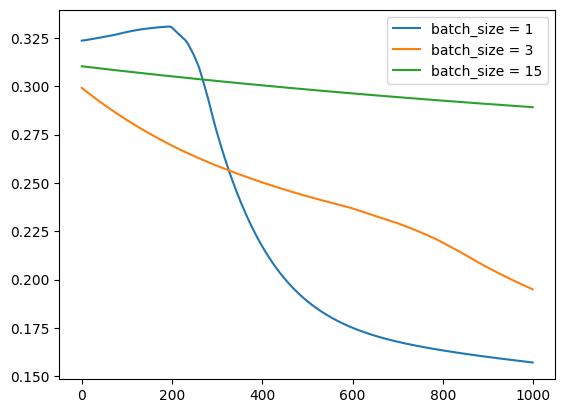

In [ ]:
import random
n_entrada = len(entrenamiento[0][0])
n_oculta = 15
n_salida = len(entrenamiento[0][1])
lr = 1e-4
er = 1e-4
# uso sigmoide xq relu a veces converge a valores != 0
funcion = 'relu'
wd = 0.0
semilla = random.randint(0, 999999999)

modelo1 = PerceptronMulticapa(
          n_entrada = n_entrada, n_oculta = n_oculta, n_salida = n_salida,
          f_act = funcion, weight_decay = wd, semilla = semilla)
modelo2 = PerceptronMulticapa(
          n_entrada = n_entrada, n_oculta = n_oculta, n_salida = n_salida,
          f_act = funcion, weight_decay = wd, semilla = semilla)
modelo3 = PerceptronMulticapa(
          n_entrada = n_entrada, n_oculta = n_oculta, n_salida = n_salida,
          f_act = funcion, weight_decay = wd, semilla = semilla)

# le cambie el shuffle a false xq parece no respetar el orden dato-etiqueta
cargador1 = DataLoader(entrenamiento, batch_size = 1, shuffle = False)
cargador2 = DataLoader(entrenamiento, batch_size = 3, shuffle = False)
cargador3 = DataLoader(entrenamiento, batch_size = 15, shuffle = False)

epocas = 1000
perdida1 = []
for i in range(epocas):
  for j in cargador1:
    x, y = j
    aux = modelo1.entrenar(x, y, lr = lr)
  with torch.no_grad():
    perdida1.append(aux)
    if aux < er:
      break
perdida2 = []
for i in range(epocas):
  for j in cargador2:
    x, y = j
    aux = modelo2.entrenar(x, y, lr = lr)
  with torch.no_grad():
    perdida2.append(aux)
    if aux < er:
      break
perdida3 = []
for i in range(epocas):
  for j in cargador3:
    x, y = j
    aux = modelo3.entrenar(x, y, lr = lr)
  with torch.no_grad():
    perdida3.append(aux)
    if aux < er:
      break

print(perdida1[-1], perdida2[-1], perdida3[-1])
import matplotlib.pyplot as plt
plt.plot(perdida1, label ='batch_size = 1')
plt.plot(perdida2, label ='batch_size = 3')
plt.plot(perdida3, label ='batch_size = 15')
plt.legend()
plt.show()

In [ ]:
import torch
from sklearn.model_selection import train_test_split

# Generar datos
n = 100
torch.manual_seed(42)
x = torch.randint(0, 11, (n, 2), dtype=torch.float32)

# Generar salidas esperadas
y = torch.zeros((n, 2), dtype=torch.float32)
y[:, 0] = (x[:, 0] + x[:, 1] > 5).float()  # 1 si suma > 5, 0 si no
y[:, 1] = (x[:, 0] - x[:, 1] < 0).float()  # 1 si resta < 0, 0 si no

# Dividir en entrenamiento y prueba
x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(
    x, y, test_size=0.3, random_state=42
)

print("Datos de entrenamiento:", x_entrenamiento.shape)
print("Datos de prueba:", x_prueba.shape)

Datos de entrenamiento: torch.Size([70, 2])
Datos de prueba: torch.Size([30, 2])


[0.2690250306893309, 0.22313082044035837, 0.1951483639963766, 0.17766618769974787, 0.16611456913951286, 0.15801838901285897, 0.15202921255757318, 0.14737819865301716, 0.1436025447153653, 0.14040862804231022, 0.13760133573580835, 0.13504631383784974, 0.13264925051878185, 0.13034423640331566, 0.1280869536515334, 0.12585028537049447, 0.12362095191498931, 0.12139642910022821, 0.11918186732995037, 0.11698705715974315, 0.1148236689333508, 0.11270302720127935, 0.11063459371030131, 0.10862518767270336, 0.10667883690932557, 0.10479707325085025, 0.1029794700313335, 0.10122425167045224, 0.0995288590138668, 0.0978904076629069, 0.09630601826185742, 0.09477302461438684, 0.09328907959666317, 0.0918521838921205, 0.09046066216792474, 0.08911310809656488, 0.08780831528819615, 0.08654520670801451, 0.08532277101759334, 0.08414001074807331, 0.08299590439014189, 0.08188938238853458, 0.08081931561610742, 0.07978451409005823, 0.07878373336775216, 0.07781568609619673, 0.07687905646436076, 0.07597251571288131, 

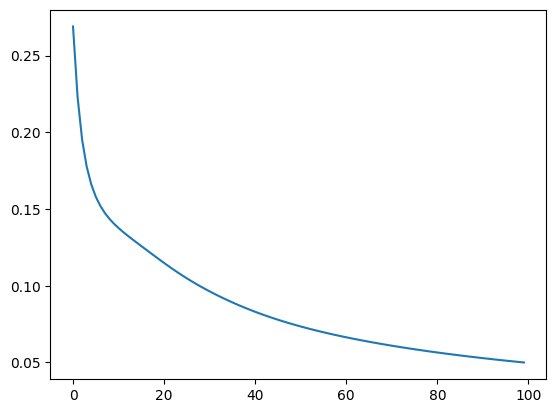

In [ ]:
n_entrada = len(x_entrenamiento[0])
n_oculta = 10
n_salida = len(y_entrenamiento[0])
lr = 1e-2

modelo = PerceptronMulticapa(
          n_entrada = n_entrada, n_oculta = n_oculta, n_salida = n_salida,
          f_act = 'sigmoid', weight_decay = 0.0)

perdida = []
epocas = 100
for i in range(epocas):
  for j in range(len(x_entrenamiento)):
    x, y = x_entrenamiento[j], y_entrenamiento[j]
    aux = modelo.entrenar(x, y, lr = lr)
  with torch.no_grad():
    perdida.append(aux)

print(perdida)
import matplotlib.pyplot as plt
plt.plot(range(epocas), perdida)
plt.show()